## Program: Plot Two Lines on the Same Graph
### Author: Johang Hernandez
#### Version: 3.2.2026.1
<br>
<p>Summary: This program plots two graphs:</p>
<ul>
<li><i>f1(t) = t - t^2</i></li>
<li><i>f2(t) = t^2 - t^3</t></li>
</ul>


In [16]:
# manage imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [17]:
# load data
df = pd.read_csv("fossil-fuel-co2-emissions-by-nation.csv")

# check for null values
isnull_result = pd.isnull(df)
nulls = isnull_result.sum()
print(nulls)

Year                           0
Country                        0
Total                          0
Solid Fuel                     0
Liquid Fuel                    0
Gas Fuel                       0
Cement                         0
Gas Flaring                    0
Per Capita                     0
Bunker fuels (Not in Total)    0
dtype: int64


In [18]:
# checkout the data
df.describe()

,Year,Total,Solid Fuel,Liquid Fuel,Gas Fuel,Cement,Gas Flaring,Per Capita,Bunker fuels (Not in Total)
count,17232.000000,1.723200e+04,1.723200e+04,17232.000000,17232.000000,17232.000000,17232.000000,17232.000000,17232.000000
mean,1961.579561,2.268712e+04,1.107010e+04,7589.085829,3189.767700,638.453865,199.718489,0.907776,560.330606
std,44.251691,1.132419e+05,6.206518e+04,39057.928585,20714.456024,6631.010202,1087.880733,2.194268,2414.320487
min,1751.000000,-1.473000e+03,-1.030000e+02,-4663.000000,-40.000000,0.000000,0.000000,-0.680000,0.000000
25%,1944.000000,1.170000e+02,0.000000e+00,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1972.000000,9.645000e+02,5.400000e+01,263.000000,0.000000,7.000000,0.000000,0.130000,4.000000
75%,1995.000000,8.059250e+03,2.002500e+03,2165.750000,71.000000,162.000000,0.000000,1.010000,133.000000
max,2014.000000,2.806634e+06,2.045156e+06,680284.000000,390719.000000,338912.000000,20520.000000,45.960000,45630.000000


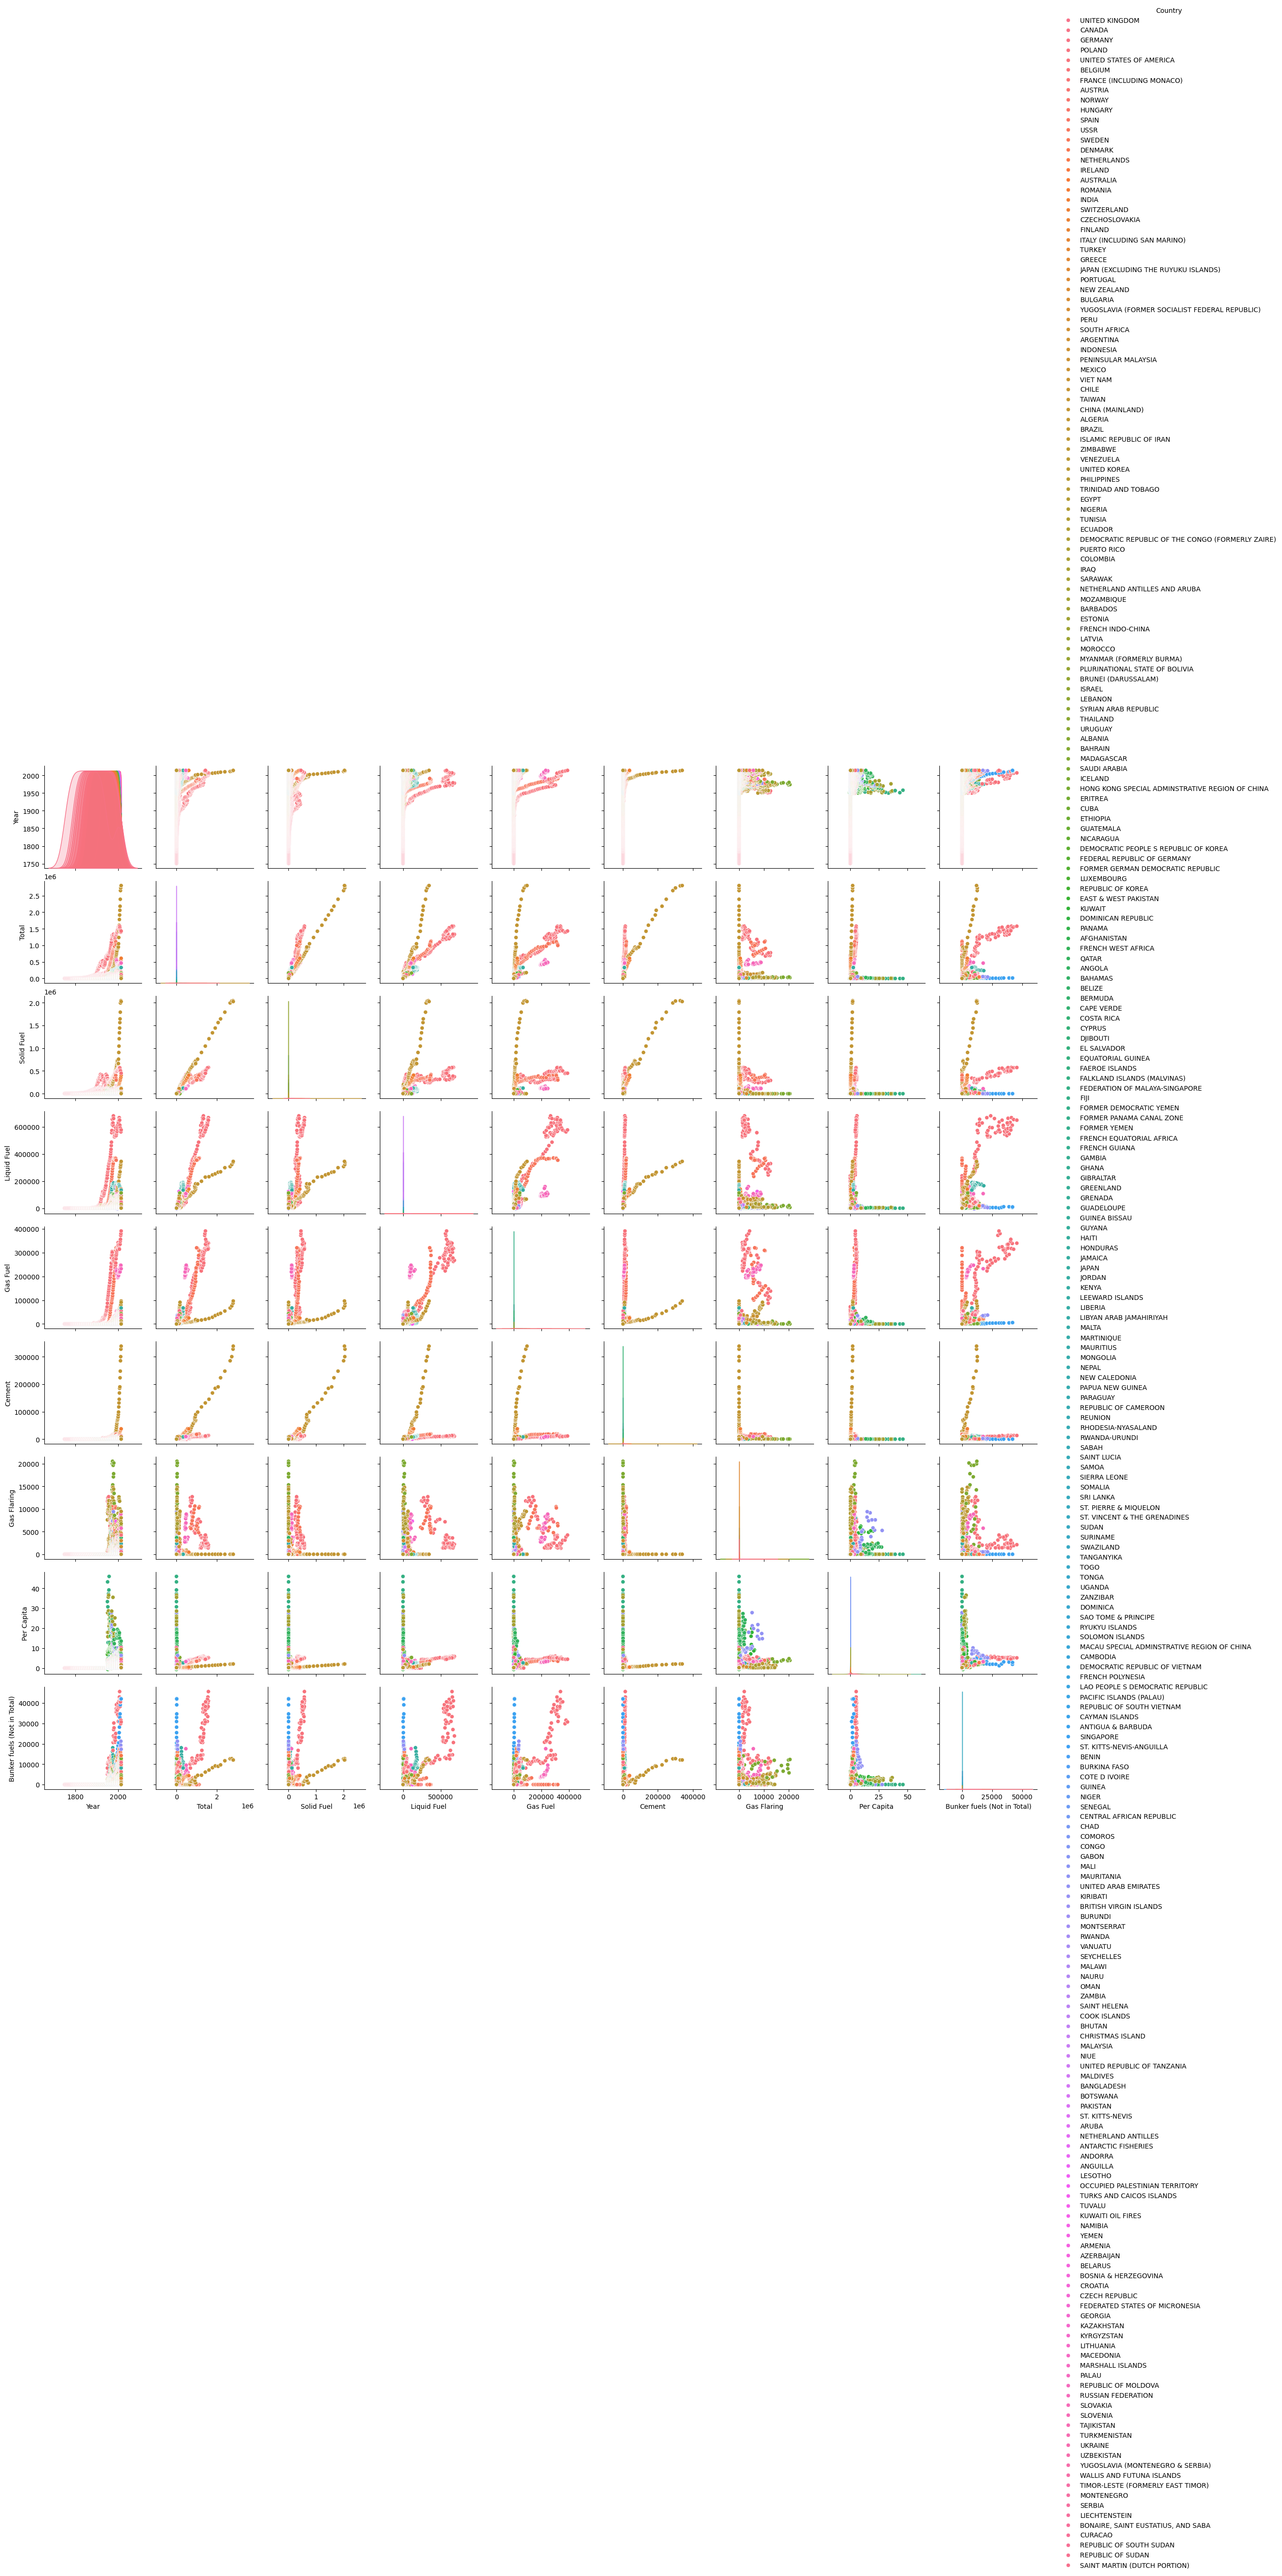

In [20]:
# plot everything

g = sns.pairplot(df, hue="Country")
g.savefig("fossil-fuel-plot.png", dpi=450)

In [107]:
# united states: total emission over years

# only get US's data
us_df = df.loc[df["Country"]=="UNITED STATES OF AMERICA"]

# make np array for years
years = us_df.loc[:, "Year"].to_numpy()

# make np array for total
emission = us_df.loc[:, "Total"].to_numpy()

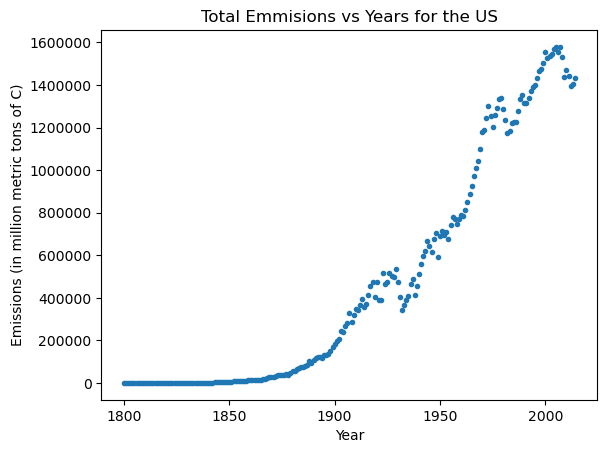

In [121]:
# display the graph of total emission vs years for the US

plt.ticklabel_format(style='plain', axis='y')
plt.plot(years, emission, linestyle="", marker=".")
plt.xlabel('Year')
plt.ylabel('Emissions (in million metric tons of C)')
plt.title('Total Emmisions vs Years for the US')
plt.show()

In [114]:
# refine by getting a moving average

interval:int = 33
interval_slice:int = interval // 2

first_year_index = interval_slice
last_year_index = len(years) - interval_slice -1

moving_year_data = np.empty(len(years)-(interval-1))
moving_emissions = np.empty(len(moving_year_data))

moving_year_index = 0
for year_index in range(first_year_index, last_year_index + 1):
    # obtain temperature anomaly subset
    anomaly_subset = emission[(year_index - interval_slice):(year_index + interval_slice)]
    # calculate the mean of the values
    temp_anomaly_mean = np.mean(anomaly_subset)
    # log current year
    moving_year_data[moving_year_index] = years[year_index]
    # log mean with year as x value
    moving_emissions[moving_year_index] = temp_anomaly_mean
    # increase moving year index
    moving_year_index += 1


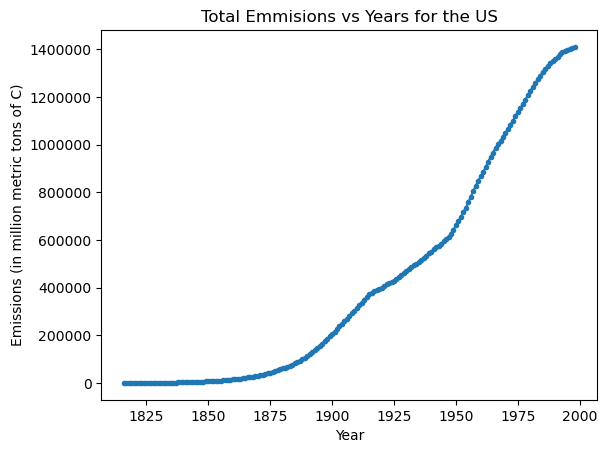

In [ ]:
# plot the new graph
plt.plot(moving_year_data, moving_emissions, marker=".")
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('Year')
plt.ylabel('Emissions (in million metric tons of C)')
plt.title('Total Emmisions vs Years for the US')
plt.show()